# Загрузка и настройка библиотек

хорошая практика: Catboost + optuna + shap,
а что с категориальными признаками?

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool, cv
import numpy as np
import math

# CATBoost

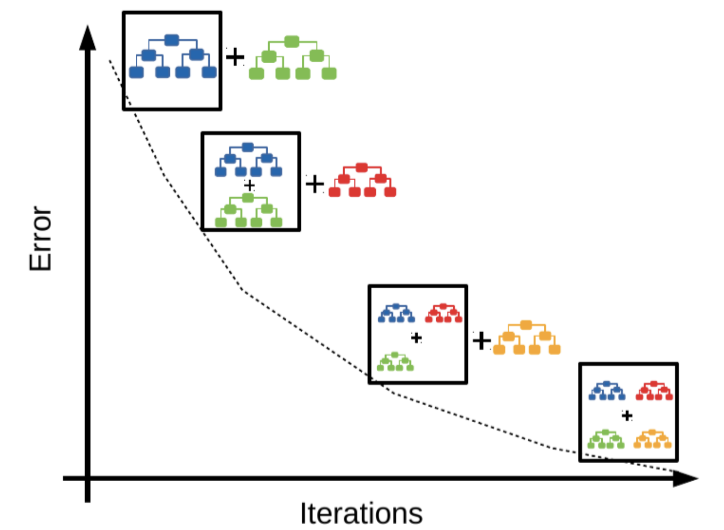

Основные понятия в бустинге:

- Базовые алгоритмы (количество)
- Функция потерь
- Производные, градиент
- Learning rate

Функция потерь:

- Функция для вычисления разницы между истинным и предсказанным значеняими
- В градиентном бустинге по функции потерь вычисляется целевая переменная для обучения следующего базового алгоритма

Learning rate - Гиперпараметр, определяющий порядок того, как мы будем корректировать веса с учётом функции потерь в градиентном спуске. Чем ниже величина, тем медленнее мы движемся по наклонной

Гиперпараметры GB

• Кол-во базовых алгоритмов (n_estimators)

• Глубина деревьев (max_depth)

• Темп обучения (learning_rate)

• Функция потерь (loss_function)

• Минимальное число объектов в листе для разделения (min_samples_split)

• Минимальное кол-во обучающих сэмплов в листе (min_samples_leaf)

• Итд

https://catboost.ai/en/docs/concepts/python-reference_catboostregressor

https://catboost.ai/en/docs/features/visualization_jupyter-notebook

В CatBoost используются симметричные «забывчивые» деревья (oblivious trees), в которых для всех узлов определенного уровня применяется одно и то же правило разбиения. Они как бы «забывают», что в левой ветви на конкретном уровне уже использовали данное правило разбиения. Такие деревья еще называют небрежными. По мнению авторов CatBoost, забывчивые деревья более устойчивы к изменению значений гиперпараметров, в меньшей степени склонны к переобучению и позволяют быстрее вычислить прогнозы.

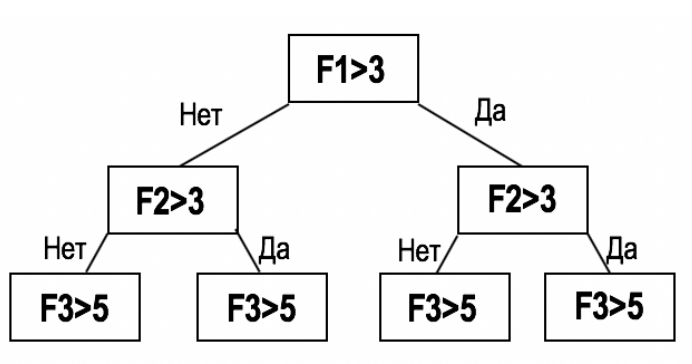

In [ ]:
!gdown 1cvCNt9EL-NurjFEJU-iRPG56ae535O3h

Downloading...
From: https://drive.google.com/uc?id=1cvCNt9EL-NurjFEJU-iRPG56ae535O3h
To: /content/Bank_Customer_Churn_Prediction.csv
100% 562k/562k [00:00<00:00, 29.1MB/s]


In [ ]:

df = pd.read_csv('/Bank_Customer_Churn_Prediction.csv', index_col='customer_id')

In [ ]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
customer_id,,,,,,,,,,,
15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
features_cat = df.select_dtypes(exclude='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='churn'),
                                                    df.churn,
                                                    test_size=0.2,
                                                    stratify=df.churn,
                                                    random_state=42)
X_train.shape, X_test.shape

((8000, 10), (2000, 10))

In [ ]:
train_dataset = Pool(X_train, y_train, cat_features=features_cat)
test_dataset = Pool(X_test, y_test, cat_features=features_cat)

catboost_model = CatBoostClassifier(n_estimators=100,
                                    loss_function='Logloss',
                                    eval_metric='AUC:hints=skip_train~false',
                                    logging_level='Silent',
                                    auto_class_weights='Balanced'
                                   )

_ = catboost_model.fit(train_dataset,
                       eval_set = test_dataset,
                       use_best_model = True,
                       verbose=False
                      )

In [ ]:
catboost_model.get_params()

{'loss_function': 'Logloss',
 'logging_level': 'Silent',
 'auto_class_weights': 'Balanced',
 'eval_metric': 'AUC:hints=skip_train~false',
 'n_estimators': 100}

In [ ]:
# у CatBoost есть собственный метод grid_search, который позволяет искать оптимальные параметры
# но на больших данных используем optuna - она быстрее

catboost_model = CatBoostClassifier(loss_function='Logloss',
                                    eval_metric='AUC:hints=skip_train~false',
                                    logging_level='Silent',
                                    auto_class_weights='Balanced',
                                    )

grid = {'iterations': [100, 150, 200],
        'learning_rate': [0.03, 0.1],
        'depth': [2, 4, 6, 8],
        'l2_leaf_reg': [0.2, 0.5, 1, 3]}

_ = catboost_model.grid_search(grid, train_dataset, cv=5, verbose=False)

In [ ]:
catboost_model.get_params()

{'loss_function': 'Logloss',
 'logging_level': 'Silent',
 'auto_class_weights': 'Balanced',
 'eval_metric': 'AUC:hints=skip_train~false',
 'depth': 4,
 'learning_rate': 0.1,
 'l2_leaf_reg': 3,
 'iterations': 100}

In [ ]:
catboost_model.best_score_


{'learn': {'Logloss': 0.4398864065212738, 'AUC': 0.8785413315869056}}

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
preds = catboost_model.predict_proba(test_dataset)[:,1]
roc_auc_score(y_test, preds)

np.float64(0.8732923987161274)

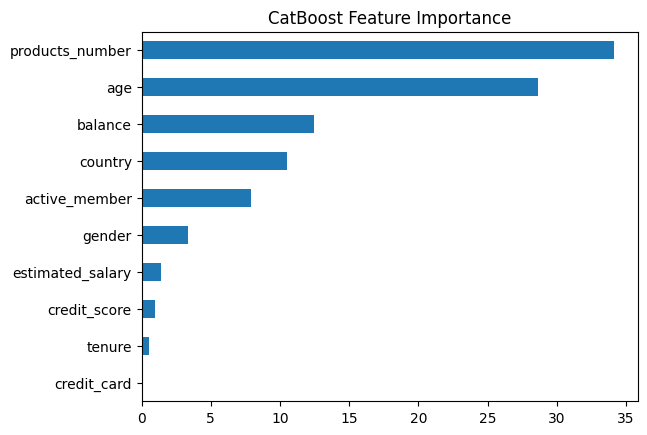

In [ ]:
pd.Series(index=catboost_model.feature_names_, data=catboost_model.feature_importances_) \
    .sort_values() \
    .plot(kind='barh')
_ = plt.title("CatBoost Feature Importance")

In [ ]:
# задаем значения гиперпараметров
cv_params = catboost_model.get_params()

In [ ]:
# запускаем перекрестную проверку (также встроенным в Catboost методом cv)
cv_data = cv(
    Pool(X_train, y_train, cat_features=features_cat),
    cv_params,
    nfold=3,
)

In [ ]:
cv_data

,iterations,test-AUC-mean,test-AUC-std,train-AUC-mean,train-AUC-std,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std
0,0,0.816843,0.006396,0.817981,0.003255,0.651969,0.000537,0.651780,0.001451
1,1,0.825531,0.013010,0.828552,0.005735,0.623950,0.004803,0.623065,0.004364
2,2,0.833124,0.010861,0.836890,0.004253,0.608182,0.004885,0.606439,0.006387
3,3,0.834116,0.010509,0.837279,0.003006,0.588716,0.003998,0.586417,0.008624
4,4,0.835851,0.009922,0.838779,0.003652,0.572254,0.003922,0.569927,0.009483
...,...,...,...,...,...,...,...,...,...
95,95,0.868786,0.010520,0.889725,0.004077,0.452426,0.012289,0.423596,0.006069
96,96,0.868878,0.010654,0.890119,0.004317,0.452204,0.012446,0.422993,0.006367
97,97,0.868886,0.010872,0.890439,0.004435,0.452003,0.012731,0.422363,0.006492
98,98,0.869040,0.010684,0.890656,0.004460,0.451739,0.012509,0.421950,0.006656


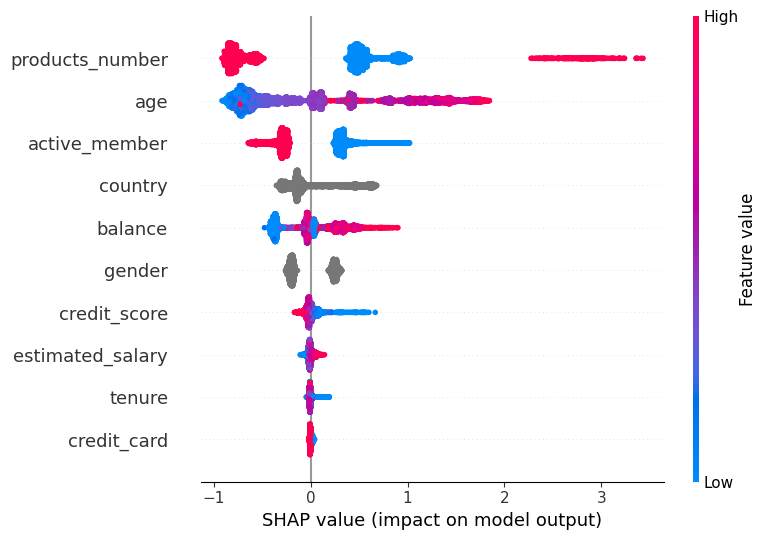

In [ ]:
import catboost
from catboost import CatBoostClassifier, Pool
import shap
import matplotlib.pyplot as plt

# Создание объяснителя SHAP
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(Pool(X_train, cat_features=features_cat))

# Визуализация важности признаков
shap.summary_plot(shap_values, X_train, plot_type="dot")

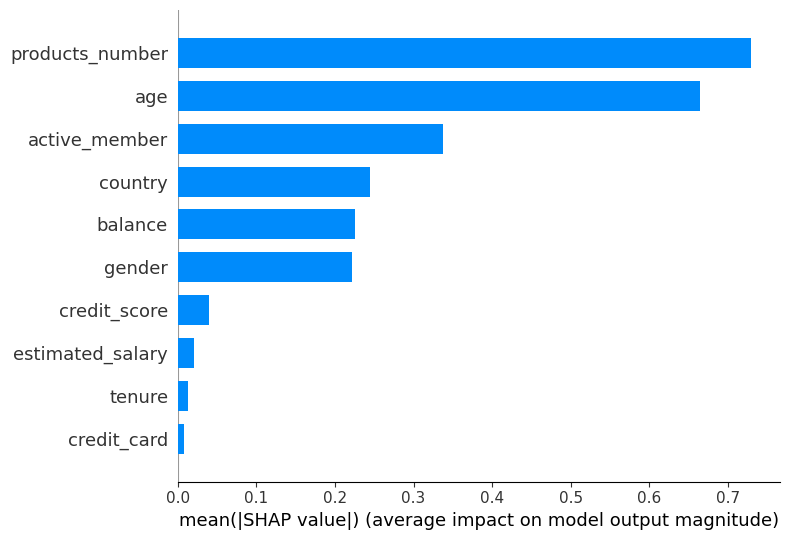

In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar")